# Eje 3a — Estrategias: spreads y butterflies

Derivados Financieros — QUANt UCEMA

Combinar calls/puts para acotar riesgo y expresar vistas direccionales *moderadas*.

**Plan del notebook:**
1. Setup (`Codigo.analytics.payoffs` + pricing)
2. Bull / Bear Call Spread
3. Bull / Bear Put Spread
4. Call Butterfly
5. Precio de la estrategia (BS por piernas)
6. Resumen


## 1) Setup

Payoffs en `Codigo.analytics.payoffs`. Precios con `precio_estrategia_nombre` (suma de vanillas BS).


In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import matplotlib.pyplot as plt
from Codigo.analytics.payoffs import (
    payoff_BullCS, payoff_BearCS, payoff_BullPS, payoff_BearPS,
    payoff_CButterflyS,
)
from Codigo.pricing import precio_estrategia_nombre
from Codigo.utils.plots import plot_payoff

S0, T, r, sigma, div = 100.0, 0.5, 0.05, 0.25, 0.0
K1, K2, K3 = 90.0, 100.0, 110.0  # low / mid / high


## 2) Bull Call Spread y Bear Call Spread

- **Bull Call Spread**: long call $K_1$ + short call $K_2$ ($K_1<K_2$). Vista alcista limitada; débito neto.
- **Bear Call Spread**: al revés (crédito). Vista bajista/neutral limitada.


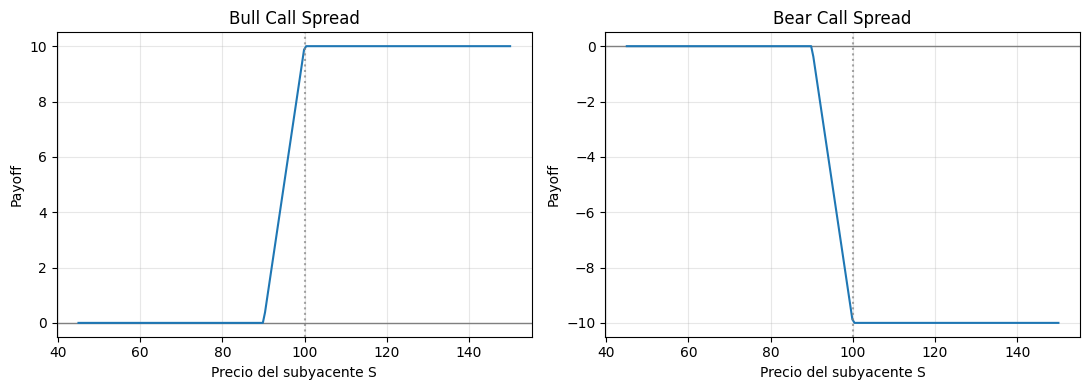

Precio (débito) Bull Call Spread: 6.1771


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_payoff(payoff_BullCS, ax=axes[0], title='Bull Call Spread', K1=K1, K2=K2)
plot_payoff(payoff_BearCS, ax=axes[1], title='Bear Call Spread', K1=K1, K2=K2)
for ax in axes:
    ax.axvline(S0, color='gray', ls=':', alpha=0.7)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

debito = precio_estrategia_nombre('bull_call_spread', S0, T, r, sigma, div, K1=K1, K2=K2)
print(f'Precio (débito) Bull Call Spread: {debito:.4f}')


## 3) Bull / Bear Put Spread

Misma lógica con puts:
- **Bull Put Spread**: short put alto + long put más bajo (crédito) — alcista/neutral.
- **Bear Put Spread**: long put alto + short put bajo (débito) — bajista.


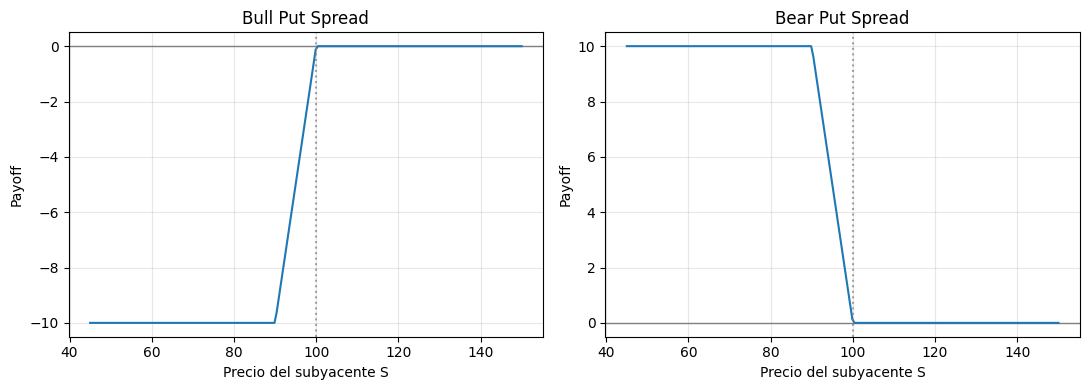

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_payoff(payoff_BullPS, ax=axes[0], title='Bull Put Spread', K1=K1, K2=K2)
plot_payoff(payoff_BearPS, ax=axes[1], title='Bear Put Spread', K1=K1, K2=K2)
for ax in axes:
    ax.axvline(S0, color='gray', ls=':', alpha=0.7)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4) Call Butterfly

Long $K_1$, short $2\times K_2$, long $K_3$ (equiespaciados). Apuesta a que $S$ termine cerca de $K_2$ (venta de volatilidad / rango).

Pérdida máxima ≈ débito neto; ganancia máxima en $S=K_2$.


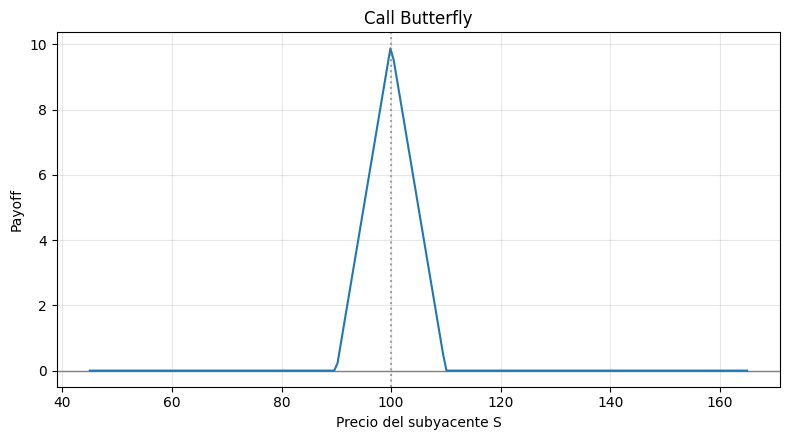

Precio Call Butterfly: 2.1429


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_payoff(payoff_CButterflyS, ax=ax, title='Call Butterfly', K1=K1, K2=K2, K3=K3)
ax.axvline(S0, color='gray', ls=':', alpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

px = precio_estrategia_nombre('call_butterfly', S0, T, r, sigma, div, K1=K1, K2=K2, K3=K3)
print(f'Precio Call Butterfly: {px:.4f}')


## 5) Comparar precios (mismo spot)

El precio de la estrategia = suma algebraica de primas de cada pierna (signo long/short).


In [5]:
nombres = {
    'bull_call_spread': dict(K1=K1, K2=K2),
    'bear_call_spread': dict(K1=K1, K2=K2),
    'bull_put_spread': dict(K1=K1, K2=K2),
    'bear_put_spread': dict(K1=K1, K2=K2),
    'call_butterfly': dict(K1=K1, K2=K2, K3=K3),
}
for nombre, kw in nombres.items():
    px = precio_estrategia_nombre(nombre, S0, T, r, sigma, div, **kw)
    print(f'{nombre:20s}  {px:8.4f}')


bull_call_spread        6.1771
bear_call_spread       -6.1771
bull_put_spread        -3.5760
bear_put_spread         3.5760
call_butterfly          2.1429


## Resumen

- Spreads verticales: vista direccional **acotada** (mejor riesgo/retorno que naked).
- Butterfly: apuesta a **poca realización** alrededor de un strike.
- En la webapp: *Payoffs y Estrategias* (Clase 1–2) para explorar break-evens en vivo.

**Siguiente notebook:** volatilidad (straddle/strangle/iron) y coberturas (covered / protective / collar).
